# Calcul des impacts environnementaux et socio-économiques par métal et scénario

Ce notebook calcule les impacts LCA environnementaux (`Total EQ`, `Total HH`) et socio-économiques (`Labor rights`, `Health & safety`, `Society`, `Employment`, `IO multiplier`) pour chaque combinaison de métal, scénario de demande et typologie d'approvisionnement.

**Logique de calcul :**
Pour chaque ligne de `DEMAND`, on multiplie les quantités des colonnes :
- `Refining CAN (mining CAN)`
- `Refining RoW (mining CAN)`
- `Refining RoW (mining RoW)`

...par les facteurs d'impact correspondants dans `Env_LCA` et `Social_eco_LCA`, en faisant correspondre le métal et le `Details`.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

FILE_PATH = 'data/For_SAM.xlsx'

## 1. Chargement des données

In [2]:
df_demand = pd.read_excel(FILE_PATH, sheet_name='Demand')
df_env    = pd.read_excel(FILE_PATH, sheet_name='Env_LCA')
df_soc    = pd.read_excel(FILE_PATH, sheet_name='Social_eco_LCA')

print(f"Demand     : {df_demand.shape}")
print(f"Env_LCA    : {df_env.shape}")
print(f"Social_eco : {df_soc.shape}")

Demand     : (1440, 12)
Env_LCA    : (23, 6)
Social_eco : (9, 12)


In [3]:
# On filtre pour uniquement garder Copper, Nickel, Cobalt dans la demand
df_demand = df_demand[df_demand['Metal'].isin(['Copper', 'Nickel', 'Cobalt'])]

In [4]:
print("=== Colonnes Demand ===")
print(df_demand.columns.tolist())
print("\n=== Colonnes Env_LCA ===")
print(df_env.columns.tolist())
print("\n=== Colonnes Social_eco_LCA ===")
print(df_soc.columns.tolist())

=== Colonnes Demand ===
['Year', 'Metal', 'Demand scenario CER', 'Production scenario CCI', 'Production scenario CCI|Refining CAN share', 'Supply scenario', 'Demand_value_t', 'Mining CAN', 'Mining RoW', 'Refining CAN (mining CAN)', 'Refining RoW (mining CAN)', 'Refining RoW (mining RoW)']

=== Colonnes Env_LCA ===
['Commodity', 'Geography', 'Reference point', 'Details', 'Total EQ (PDF.m2.yr)', 'Total HH (DALY)']

=== Colonnes Social_eco_LCA ===
['Metal', 'Details', '1 Labor rights & decent work', '2 Health & safety', '3 Society', 'Employment (Global) (full time job equivalent/CAD)', 'IO multiplier (Global economy)', 'Labor rights & decent work (physique)', 'Health & safety (physique)', 'Society (physique)', 'Employment (physique)', 'IO multiplier (physique)']


In [5]:
print("=== Métaux dans Demand ===", df_demand['Metal'].unique())
print("\n=== Métaux dans Env_LCA ===", df_env['Commodity'].dropna().unique())
print("\n=== Métaux dans Social_eco_LCA ===", df_soc['Metal'].dropna().unique())

=== Métaux dans Demand === ['Cobalt' 'Copper' 'Nickel']

=== Métaux dans Env_LCA === ['Cobalt' 'Copper' 'Nickel']

=== Métaux dans Social_eco_LCA === ['Copper' 'Nickel' 'Cobalt']


## 2. Construction des tables de facteurs d'impact

On filtre les lignes sans `Commodity`/`Metal` (lignes agrégées) et on indexe par `(métal, Details)` pour un lookup rapide.

In [6]:
# Env_LCA : garder uniquement les lignes avec un Details correspondant aux 3 typologies
supply_types = ['Refining CAN (mining CAN)', 'Refining RoW (mining CAN)', 'Refining RoW (mining RoW)']

env_factors = (
    df_env[df_env['Details'].isin(supply_types)]
    .set_index(['Commodity', 'Details'])
    [['Total EQ (PDF.m2.yr)', 'Total HH (DALY)']]
)
print("Facteurs environnementaux disponibles :")
print(env_factors)

Facteurs environnementaux disponibles :
                                     Total EQ (PDF.m2.yr)  Total HH (DALY)
Commodity Details                                                         
Cobalt    Refining CAN (mining CAN)              8.342655         0.000077
          Refining RoW (mining CAN)              8.880526         0.000082
          Refining RoW (mining RoW)              8.932025         0.000083
Copper    Refining CAN (mining CAN)             47.250492         0.000036
          Refining RoW (mining CAN)             52.212409         0.000057
          Refining RoW (mining RoW)             49.587501         0.000058
Nickel    Refining CAN (mining CAN)              3.753558         0.000036
          Refining RoW (mining CAN)              4.166736         0.000040
          Refining RoW (mining RoW)              4.273833         0.000041


In [7]:
# Social_eco_LCA : indexé par (Metal, Details)
soc_cols = [
    'Labor rights & decent work (physique)',
    'Health & safety (physique)',
    'Society (physique)',
    'Employment (physique)',
    'IO multiplier (physique)'
]

soc_factors = (
    df_soc[df_soc['Details'].isin(supply_types)]
    .set_index(['Metal', 'Details'])
    [soc_cols]
)
print("Facteurs socio-économiques disponibles :")
print(soc_factors)

Facteurs socio-économiques disponibles :
                                  Labor rights & decent work (physique)  \
Metal  Details                                                            
Copper Refining CAN (mining CAN)                               0.197810   
       Refining RoW (mining CAN)                               0.327726   
       Refining RoW (mining RoW)                               0.570953   
Nickel Refining CAN (mining CAN)                               0.446936   
       Refining RoW (mining CAN)                               0.740470   
       Refining RoW (mining RoW)                               2.422883   
Cobalt Refining CAN (mining CAN)                               0.267735   
       Refining RoW (mining CAN)                               0.955587   
       Refining RoW (mining RoW)                               1.105743   

                                  Health & safety (physique)  \
Metal  Details                                                 
Coppe

## 3. Calcul des impacts

Pour chaque ligne de `DEMAND` et chaque typologie d'approvisionnement :

$$\text{Impact}_{i} = Q_{i} \times f_{\text{métal, typologie}}$$

Les impacts des 3 typologies sont **sommés** pour obtenir l'impact total de la ligne.

In [8]:
# Colonnes de quantité dans Demand, associées à chaque Details
demand_qty_map = {
    'Refining CAN (mining CAN)': 'Refining CAN (mining CAN)',
    'Refining RoW (mining CAN)': 'Refining RoW (mining CAN)',
    'Refining RoW (mining RoW)': 'Refining RoW (mining RoW)',
}

env_output_cols  = ['Total EQ (PDF.m2.yr)', 'Total HH (DALY)']
soc_output_cols  = soc_cols
key_cols         = ['Year', 'Metal', 'Demand scenario CER', 'Production scenario CCI',
                    'Production scenario CCI|Refining CAN share', 'Supply scenario']

results = []

for _, row in df_demand.iterrows():
    metal = row['Metal']
    record = {c: row[c] for c in key_cols}

    env_total  = {c: 0.0 for c in env_output_cols}
    soc_total  = {c: 0.0 for c in soc_output_cols}

    for details, qty_col in demand_qty_map.items():
        qty = row.get(qty_col, 0)
        if pd.isna(qty) or qty == 0:
            continue

        # -- Impact environnemental --
        try:
            ef = env_factors.loc[(metal, details)]
            for c in env_output_cols:
                env_total[c] += qty * ef[c]
        except KeyError:
            pass  # métal sans facteur env pour cette typologie (ex. Graphite, Lithium)

        # -- Impact socio-économique --
        try:
            sf = soc_factors.loc[(metal, details)]
            for c in soc_output_cols:
                soc_total[c] += qty * sf[c]
        except KeyError:
            pass

    record.update(env_total)
    record.update(soc_total)
    results.append(record)

df_results = pd.DataFrame(results)
print(f"Résultats calculés : {df_results.shape[0]} lignes")
df_results.head()

Résultats calculés : 720 lignes


,Year,Metal,Demand scenario CER,Production scenario CCI,Production scenario CCI|Refining CAN share,Supply scenario,Total EQ (PDF.m2.yr),Total HH (DALY),Labor rights & decent work (physique),Health & safety (physique),Society (physique),Employment (physique),IO multiplier (physique)
0,2025,Cobalt,Canada Net-zero,Existing production,Current shares,NIMBY,85357.295501,0.788477,10566.831042,19507.167443,8505.503802,11.071711,155049.295968
1,2025,Cobalt,Canada Net-zero,Existing production,Current shares,Status Quo,84481.066104,0.780520,9316.870701,17186.218213,7412.266896,9.428265,149644.552318
2,2025,Cobalt,Canada Net-zero,Production potential,Current shares,Expansion Extractive,84391.686178,0.779708,9189.368287,16949.469398,7300.751082,9.260626,149093.240536
3,2025,Cobalt,Canada Net-zero,Production potential,Current shares,Expansion Extractive+Circularity,84391.686178,0.779708,9189.368287,16949.469398,7300.751082,9.260626,149093.240536
4,2025,Cobalt,Canada Net-zero,Production potential,100% CAN,Integrated,84360.279669,0.779425,9149.204313,16872.707290,7265.374788,9.256243,149081.841886


In [9]:
df_results

,Year,Metal,Demand scenario CER,Production scenario CCI,Production scenario CCI|Refining CAN share,Supply scenario,Total EQ (PDF.m2.yr),Total HH (DALY),Labor rights & decent work (physique),Health & safety (physique),Society (physique),Employment (physique),IO multiplier (physique)
0,2025,Cobalt,Canada Net-zero,Existing production,Current shares,NIMBY,85357.295501,0.788477,10566.831042,1.950717e+04,8505.503802,1.107171e+01,1.550493e+05
1,2025,Cobalt,Canada Net-zero,Existing production,Current shares,Status Quo,84481.066104,0.780520,9316.870701,1.718622e+04,7412.266896,9.428265e+00,1.496446e+05
2,2025,Cobalt,Canada Net-zero,Production potential,Current shares,Expansion Extractive,84391.686178,0.779708,9189.368287,1.694947e+04,7300.751082,9.260626e+00,1.490932e+05
3,2025,Cobalt,Canada Net-zero,Production potential,Current shares,Expansion Extractive+Circularity,84391.686178,0.779708,9189.368287,1.694947e+04,7300.751082,9.260626e+00,1.490932e+05
4,2025,Cobalt,Canada Net-zero,Production potential,100% CAN,Integrated,84360.279669,0.779425,9149.204313,1.687271e+04,7265.374788,9.256243e+00,1.490818e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,2040,Nickel,Global Net-zero,Existing production,Current shares,NIMBY,831149.125562,7.896926,471187.684078,1.051068e+06,385868.721166,1.424883e+07,5.231038e+06
716,2040,Nickel,Global Net-zero,Existing production,Current shares,Status Quo,819804.105853,7.793536,421573.237318,9.348745e+05,342593.184804,1.267365e+07,4.644372e+06
717,2040,Nickel,Global Net-zero,Production potential,Current shares,Expansion Extractive,744939.989637,7.111373,97553.092467,1.763890e+05,59986.061405,2.391221e+06,8.132023e+05
718,2040,Nickel,Global Net-zero,Production potential,Current shares,Expansion Extractive+Circularity,744939.989637,7.111373,97553.092467,1.763890e+05,59986.061405,2.391221e+06,8.132023e+05


In [10]:
df_results.to_excel(r"results/for_SAM/results_for_SAM.xlsx")

In [11]:
# Enlever le scénario supply de circularité pour le moment
df_results = df_results[df_results['Supply scenario'] != 'Expansion Extractive+Circularity'].copy()

# 4. Visualisations

## 4.1 Préparation des données pour les graphiques

In [12]:
# ── Colonnes d'impact ──────────────────────────────────────────────────────────
IMPACT_COLS = [
    'Total EQ (PDF.m2.yr)',
    'Total HH (DALY)',
    'Labor rights & decent work (physique)',
    'Health & safety (physique)',
    'Society (physique)',
    'Employment (physique)',
    'IO multiplier (physique)',
]

# Noms courts pour les axes
IMPACT_LABELS = {
    'Total EQ (PDF.m2.yr)'                  : 'EQ\n(PDF.m2.yr)',
    'Total HH (DALY)'                        : 'HH\n(DALY)',
    'Labor rights & decent work (physique)'  : 'Labor\nrights',
    'Health & safety (physique)'             : 'Health\n& safety',
    'Society (physique)'                     : 'Society',
    'Employment (physique)'                  : 'Employment',
    'IO multiplier (physique)'               : 'IO\nmultiplier',
}

KEY_COLS = ['Year', 'Metal', 'Demand scenario CER',
            'Production scenario CCI', 'Production scenario CCI|Refining CAN share',
            'Supply scenario']

In [13]:
# Filtrer la période 2025–2040
df_period = df_results[(df_results['Year'] >= 2025) & (df_results['Year'] <= 2040)].copy()

GROUP_COLS = ['Metal', 'Demand scenario CER',
              'Production scenario CCI', 'Production scenario CCI|Refining CAN share',
              'Supply scenario']

df_cum = (
    df_period
    .groupby(GROUP_COLS)[IMPACT_COLS]
    .sum()
    .reset_index()
)

print(f'Lignes cumulées : {len(df_cum):,}')
df_cum.head()

Lignes cumulées : 36


,Metal,Demand scenario CER,Production scenario CCI,Production scenario CCI|Refining CAN share,Supply scenario,Total EQ (PDF.m2.yr),Total HH (DALY),Labor rights & decent work (physique),Health & safety (physique),Society (physique),Employment (physique),IO multiplier (physique)
0,Cobalt,Canada Net-zero,Existing production,Current shares,NIMBY,1.642355e+07,151.710355,2.033158e+06,3.753363e+06,1.636539e+06,2130.301852,2.983295e+07
1,Cobalt,Canada Net-zero,Existing production,Current shares,Status Quo,1.641252e+07,151.610231,2.017430e+06,3.724159e+06,1.622783e+06,2109.622376,2.976494e+07
2,Cobalt,Canada Net-zero,Production potential,100% CAN,Integrated,1.636788e+07,151.204971,1.954004e+06,3.606267e+06,1.567296e+06,2028.934073,2.949975e+07
3,Cobalt,Canada Net-zero,Production potential,Current shares,Expansion Extractive,1.636963e+07,151.220748,1.956247e+06,3.610553e+06,1.569271e+06,2029.178782,2.950039e+07
4,Cobalt,Current Measures,Existing production,Current shares,NIMBY,6.647505e+06,61.405440,8.229298e+05,1.519191e+06,6.623966e+05,862.249139,1.207502e+07


In [14]:
# ── PARAMÈTRE À MODIFIER ──────────────────────────────────────────────────────
DEMAND_SCENARIO = 'Canada Net-zero'
# ─────────────────────────────────────────────────────────────────────────────

df_filtered = df_cum[df_cum['Demand scenario CER'] == DEMAND_SCENARIO].copy()

print(f'Scénario sélectionné : « {DEMAND_SCENARIO} »')
print(f'Lignes filtrées : {len(df_filtered)}')
print(f'Métaux : {df_filtered["Metal"].unique().tolist()}')
print(f'Supply scenarios : {df_filtered["Supply scenario"].unique().tolist()}')
df_filtered.head()

Scénario sélectionné : « Canada Net-zero »
Lignes filtrées : 12
Métaux : ['Cobalt', 'Copper', 'Nickel']
Supply scenarios : ['NIMBY', 'Status Quo', 'Integrated', 'Expansion Extractive']


,Metal,Demand scenario CER,Production scenario CCI,Production scenario CCI|Refining CAN share,Supply scenario,Total EQ (PDF.m2.yr),Total HH (DALY),Labor rights & decent work (physique),Health & safety (physique),Society (physique),Employment (physique),IO multiplier (physique)
0,Cobalt,Canada Net-zero,Existing production,Current shares,NIMBY,1.642355e+07,151.710355,2.033158e+06,3.753363e+06,1.636539e+06,2130.301852,2.983295e+07
1,Cobalt,Canada Net-zero,Existing production,Current shares,Status Quo,1.641252e+07,151.610231,2.017430e+06,3.724159e+06,1.622783e+06,2109.622376,2.976494e+07
2,Cobalt,Canada Net-zero,Production potential,100% CAN,Integrated,1.636788e+07,151.204971,1.954004e+06,3.606267e+06,1.567296e+06,2028.934073,2.949975e+07
3,Cobalt,Canada Net-zero,Production potential,Current shares,Expansion Extractive,1.636963e+07,151.220748,1.956247e+06,3.610553e+06,1.569271e+06,2029.178782,2.950039e+07
12,Copper,Canada Net-zero,Existing production,Current shares,NIMBY,9.527231e+08,1106.347640,1.096970e+07,1.820136e+07,9.582401e+06,14143.361231,2.262583e+08


## 2. Fonctions de graphiques

In [15]:
import matplotlib.pyplot as plt

In [19]:
# Palette de couleurs par supply scenario
SUPPLY_COLORS = {
    'NIMBY'                          : '#E74C3C',
    'Status Quo'                     : '#F39C12',
    'Expansion Extractive'           : '#3498DB',
    'Expansion Extractive+Circularity': '#2ECC71',
    'Integrated'                     : '#9B59B6',
}

def plot_normalized_impacts(
    df_source,
    metal,
    demand_scenario=None,
    norm='max',          # 'max' | 'minmax' | 'zscore'
    figsize=(12, 5),
    title_suffix='',
    save_path=None,      # ex. 'figures/Cobalt_Canada_Net-zero.png'
):
    """
    Trace un graphique en barres groupées des impacts normalisés par indicateur
    pour un métal donné, en comparant les scénarios de supply.

    Paramètres
    ----------
    df_source      : DataFrame cumulé (issu de df_cum ou df_filtered)
    metal          : str, e.g. 'Cobalt'
    demand_scenario: str optionnel – filtre sur Demand scenario CER
    norm           : méthode de normalisation
                     'max'     → valeur / max(valeurs) de l'indicateur
                     'minmax'  → (valeur - min) / (max - min)
                     'zscore'  → (valeur - mean) / std
    figsize        : tuple
    title_suffix   : str ajouté au titre
    """
    data = df_source[df_source['Metal'] == metal].copy()
    if demand_scenario:
        data = data[data['Demand scenario CER'] == demand_scenario]

    if data.empty:
        print(f'Aucune donnée pour {metal} / {demand_scenario}')
        return

    # Agréger par Supply scenario (somme si plusieurs prod. scenarios)
    data = data.groupby('Supply scenario')[IMPACT_COLS].sum()

    # ── Normalisation ────────────────────────────────────────────────────────
    if norm == 'max':
        col_max = data.max(axis=0).replace(0, np.nan)
        data_norm = data.div(col_max, axis=1).fillna(0)
        ylabel = 'Impact normalisé (÷ max)'
    elif norm == 'minmax':
        col_min = data.min(axis=0)
        col_max = data.max(axis=0)
        denom = (col_max - col_min).replace(0, np.nan)
        data_norm = (data - col_min).div(denom, axis=1).fillna(0)
        ylabel = 'Impact normalisé min–max [0, 1]'
    elif norm == 'zscore':
        data_norm = data.apply(lambda col: (col - col.mean()) / col.std() if col.std() > 0 else col * 0)
        ylabel = 'Z-score'
    else:
        raise ValueError(f'norm doit être "max", "minmax" ou "zscore" (reçu: {norm!r})')

    # ── Tracé ─────────────────────────────────────────────────────────────────
    supply_scenarios = data_norm.index.tolist()
    n_indicators = len(IMPACT_COLS)
    n_supply = len(supply_scenarios)

    x = np.arange(n_indicators)
    width = 0.8 / n_supply
    offsets = np.linspace(-(n_supply - 1) / 2, (n_supply - 1) / 2, n_supply) * width

    fig, ax = plt.subplots(figsize=figsize)

    for i, scenario in enumerate(supply_scenarios):
        values = [data_norm.loc[scenario, col] for col in IMPACT_COLS]
        color  = SUPPLY_COLORS.get(scenario, f'C{i}')
        bars   = ax.bar(x + offsets[i], values, width=width * 0.92,
                        label=scenario, color=color, alpha=0.88, edgecolor='white', linewidth=0.5)

    # Axe X
    ax.set_xticks(x)
    ax.set_xticklabels([IMPACT_LABELS[c] for c in IMPACT_COLS], fontsize=10)

    # Lignes de référence
    if norm in ('max', 'minmax'):
        ax.axhline(1, color='black', linewidth=0.8, linestyle='--', alpha=0.4, label='Max')
        ax.set_ylim(0, 1.15)
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)

    # Grille et style
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle=':', alpha=0.6)
    ax.set_ylabel(ylabel, fontsize=11)
    #ax.set_xlabel('Catégorie d\'impact', fontsize=11)

    demand_label = demand_scenario if demand_scenario else 'tous scénarios'
    ax.set_title(
        f'{metal}  ·  {demand_label}  ·  impacts cumulés 2025–2040{title_suffix}\n'
        f'Normalisation : {norm}',
        fontsize=12, fontweight='bold'
    )

    ax.legend(title='Supply scenario', bbox_to_anchor=(1.01, 1), loc='upper left',
              fontsize=9, title_fontsize=9, framealpha=0.9)

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f'Saved → {save_path}')

    plt.show()
    return fig

Saved → results/for_SAM/Cobalt_Canada_Net-zero_max.png


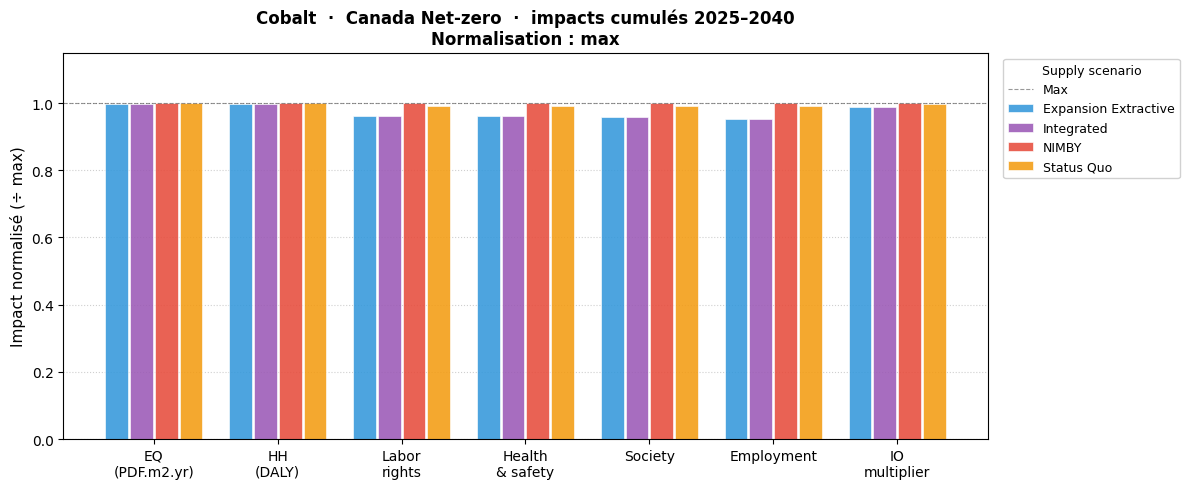

Saved → results/for_SAM/Copper_Canada_Net-zero_max.png


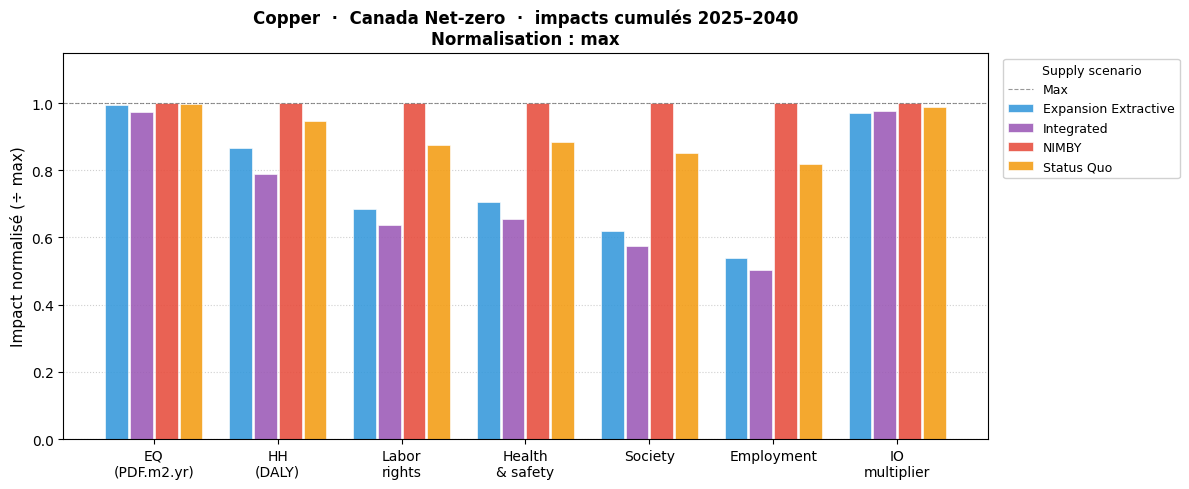

Saved → results/for_SAM/Nickel_Canada_Net-zero_max.png


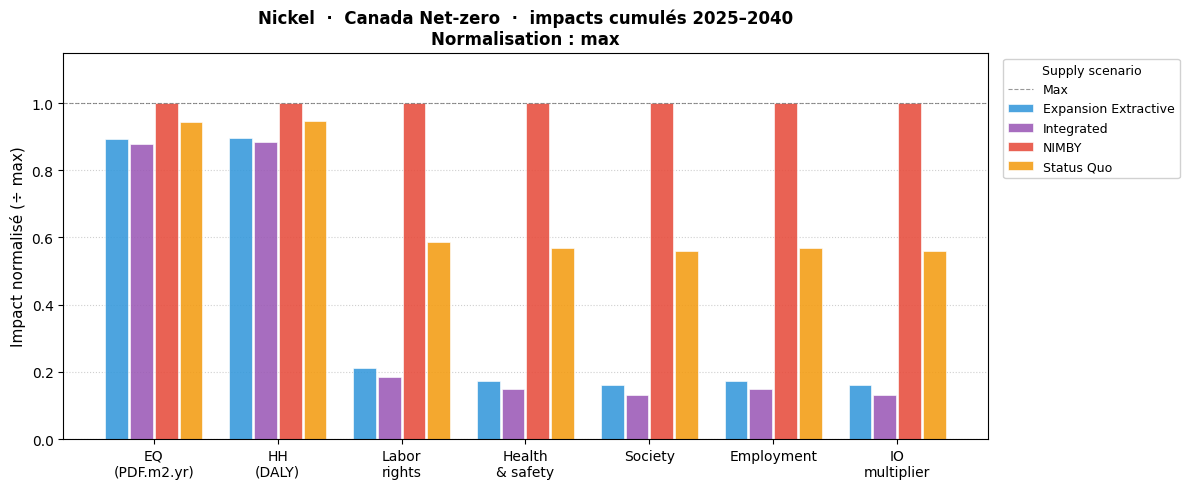

In [20]:
import os
os.makedirs(r"results\for_SAM", exist_ok=True)

for metal in df_filtered['Metal'].unique():
    fname = f"results/for_SAM/{metal}_{DEMAND_SCENARIO.replace(' ', '_')}_max.png"
    plot_normalized_impacts(
        df_source=df_filtered,
        metal=metal,
        demand_scenario=DEMAND_SCENARIO,
        norm='max',
        save_path=fname,
    )